<a href="https://colab.research.google.com/github/Sebas-Atehortua/Integracion-de-Datos-y-Prospectiva/blob/main/Integraci%C3%B3n_DB_EPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Integración de Datos y Análisis de Credibilidad - Caso Entidades Promotoras de Salud (EPS)**

El siguiente modelo tiene como objetivo integrar la información de pacientes de la sucursal de Sabaneta que está próxima a cerrar hacia las demás sucursales de la red prestadora de salud. Se trata de garantizar una reubicación estadísticamente consistente, que mitigue el impacto operativo y mantenga estable el perfil clínico de las sucursales que recibirán a estos pacientes.

Dado que la información de los pacientes varía entre las sucursales y la estructura poblacional de cada clínica es distinta, se emplea la **Teoría de la Credibilidad** para determinar el grado de afinidad o compatibilidad de la sucursal de Sabaneta con las demás sedes. Posteriormente, se utilizan métodos aleatorios (Valor de Pertenencia y Aceptación/Rechazo) para la asignación óptima de cada paciente.

Para seleccionar la variable de interés, se tuvo en cuenta las variables que logran replicarse en la base de datos:

*   **Índice de Masa Corporal** (BMI) como unidad física y fundamental para caracterizar a los pacientes propensos a sufrir de diabetes.
*   **Función de Pedrigrí de Diabetes** (DiabetesPedigreeFunction) como dato que refleja la herencia genética

Con ambas variables se podría construir un modelo apropiado, sin embargo, a diferencia de la función de pedrigrí, el BMI suele seguir una distribución de campana en la que la mayoría de los pacientes se sitúan en el centro, facilitando una media hipotética estable para la construcción de los métodos aleatorios que se van a emplear, por lo tanto se toma el **BMI** como variable de referencia para la integración.

Otra variable es Glucosa, sin embargo, esta al estar medida únicamente en 5 de las 6 sucursales y no en su totalidad esta variable alteraría el análisis y hará que los datos no se integren correctamente.

0. Se cargan las librerías de trabajo

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Se define el formato y se ajustan los decimales
sns.set_theme(style="whitegrid")
pd.options.display.float_format = '{:.4f}'.format

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Se montan los archivos de trabajo

**Nota**: Dado que el archivo tiene múltiples hojas y algunas difieren en columnas, cargaremos todas las hojas y extraeremos únicamente la variable de interés (BMI) para evitar conflictos.

In [47]:
# Cargar base de datos unificada con múltiples hojas
db = '/content/drive/MyDrive/Integración de Datos/Parcial #1/3. Parcial - medical_attention_data.xlsx'
hojas = ['Bello', 'Envigado', 'Medellín', 'Itagui', 'Sabaneta', 'Caldas']
datos_sucursales = {}

var_ref = 'BMI'

# Extracción iterativa de la variable de referencia por sucursal

for hoja in hojas:
    df = pd.read_excel(db, sheet_name=hoja)
    datos_sucursales[hoja] = df[var_ref].dropna().values

sabaneta_bmi = datos_sucursales['Sabaneta']

2. Se crea la función de caracterización de las variables

In [48]:
def caracterizacion(X, nombre, plot=True):
    print(f"\n===== {nombre} =====")
    media      = round(np.mean(X), 2)
    varianza   = round(np.var(X), 2)
    desviacion = round(np.std(X), 2)
    asimetria  = round(skew(X), 2)
    curtosis  = round(kurtosis(X), 2)

    print("N (pacientes) :", len(X))
    print("Media         :", media)
    print("Varianza      :", varianza)
    print("Desviación    :", desviacion)
    print("Asimetría     :", asimetria)
    print("Curtosis      :", curtosis)

    if plot:
        plt.figure(figsize=(6, 4))
        sns.histplot(X, bins=15, kde=True, color='teal')
        plt.title(f"Distribución de {var_ref} – {nombre}")
        plt.xlabel(f"{var_ref} (kg/m²)")
        plt.ylabel("Frecuencia de ocurrencia")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return media, varianza, desviacion, asimetria, curtosis

2.1. Se caracterizan las variables en medidas de tendencia central antes de la integración


===== Sabaneta (sucursal a cerrar) =====
N (pacientes) : 621
Media         : 32.99
Varianza      : 97.75
Desviación    : 9.89
Asimetría     : -0.02
Curtosis      : -1.15


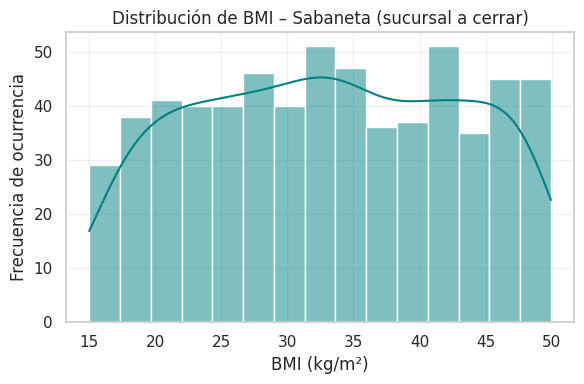


===== Bello =====
N (pacientes) : 502
Media         : 32.99
Varianza      : 97.45
Desviación    : 9.87
Asimetría     : -0.05
Curtosis      : -1.15


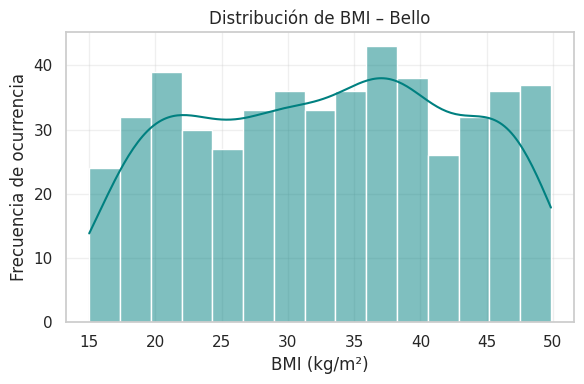


===== Envigado =====
N (pacientes) : 792
Media         : 32.55
Varianza      : 96.45
Desviación    : 9.82
Asimetría     : -0.03
Curtosis      : -1.12


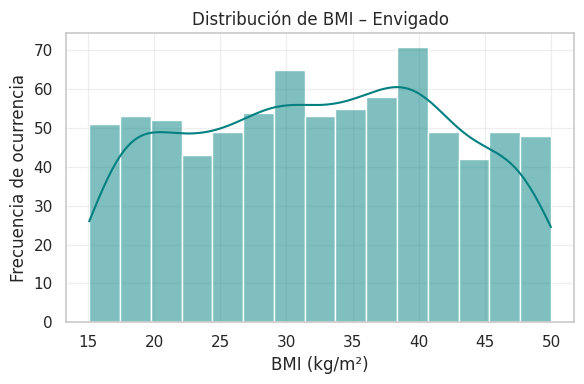


===== Medellín =====
N (pacientes) : 895
Media         : 32.88
Varianza      : 99.41
Desviación    : 9.97
Asimetría     : -0.07
Curtosis      : -1.17


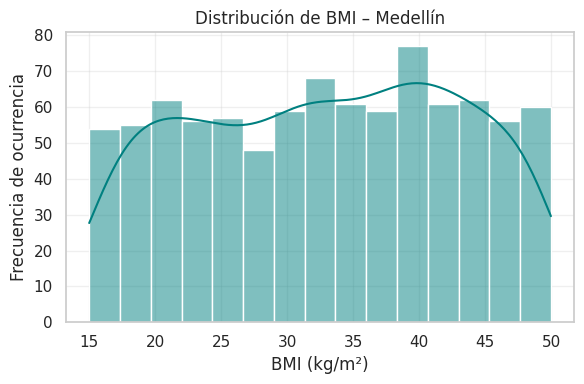


===== Itagui =====
N (pacientes) : 684
Media         : 32.24
Varianza      : 99.2
Desviación    : 9.96
Asimetría     : 0.03
Curtosis      : -1.16


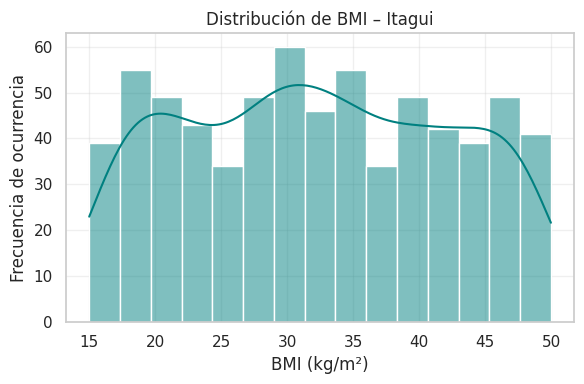


===== Caldas =====
N (pacientes) : 909
Media         : 33.06
Varianza      : 104.12
Desviación    : 10.2
Asimetría     : -0.11
Curtosis      : -1.19


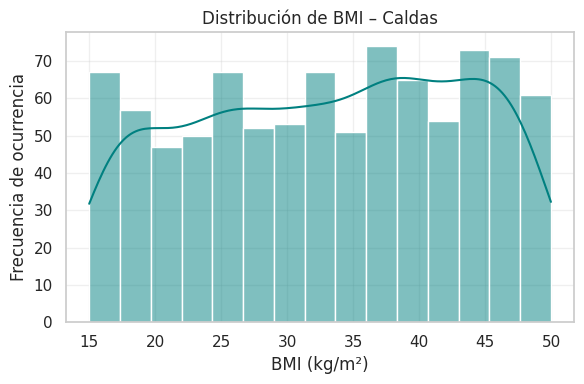

Gráfico que reune la distribución de todas las variables


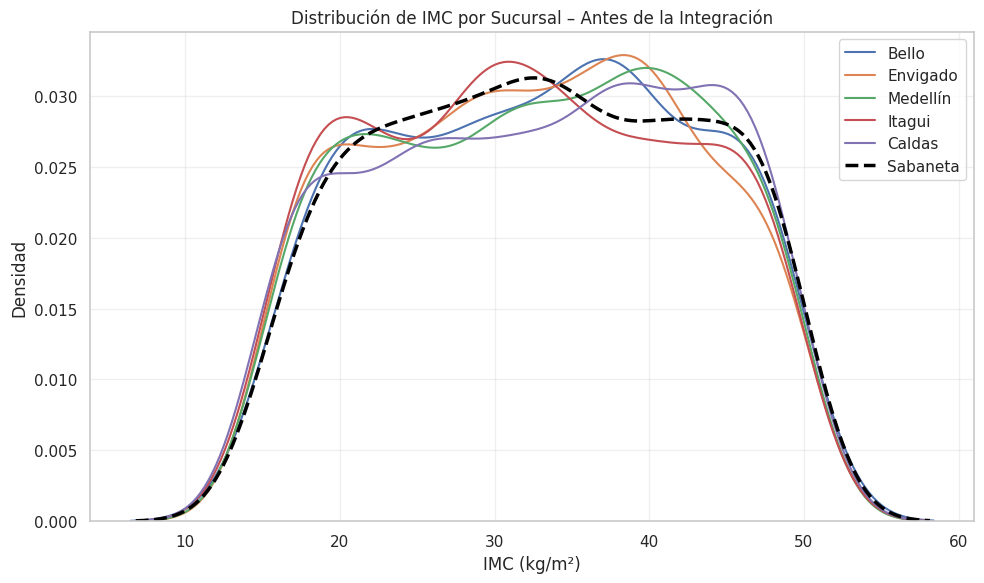

In [49]:
# Sabaneta
u_sab, var_sab, sig_sab, ase_sab, kur_sab = caracterizacion(
    sabaneta_bmi, "Sabaneta (sucursal a cerrar)")
n_sab = len(sabaneta_bmi)

# Demás sucursales
stats = {}
for nombre, datos in datos_sucursales.items():
    if nombre == 'Sabaneta':
        continue
    u, var, sig, ase, kur = caracterizacion(datos, nombre)
    stats[nombre] = {'u': u, 'var': var, 'sig': sig,
                     'ase': ase, 'kur': kur,
                     'n': len(datos), 'X': datos}

# Visualización comparativa
plt.figure(figsize=(10, 6))
for nombre, s in stats.items():
    sns.kdeplot(s['X'], label=nombre)
sns.kdeplot(sabaneta_bmi, label='Sabaneta', linewidth=2.5,
            linestyle='--', color='black')

print("Gráfico que reune la distribución de todas las variables")


plt.title("Distribución de IMC por Sucursal – Antes de la Integración")
plt.xlabel("IMC (kg/m²)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Como se observa en la salida del modelo, la variable BMI en la sucursal de Sabaneta presenta una media de 32.99, lo que sitúa al paciente promedio en un rango de obesidad grado I. La desviación estándar de 9.89 sugiere una dispersión moderada, permitiendo que el modelo capture una amplia gama de perfiles clínicos.

3. **Se aplica la Teoría de la Credibilidad**

Se calcula el factor de credibiidad para cada una de las sucursales receptoras. Recordemos que un factor de credibilidad Z cercano a 1 estaría indicando alta afinidad con Sabaneta, mientras que Z cercano a 0 indica baja compatibilidad.

In [50]:
# Se configuran pandas para que muestren 4 decimales y no usen la notación científica
pd.options.display.float_format = '{:.4f}'.format

afinidad_resultados = []
ND_sab = len(sabaneta_bmi)

for sucursal, datos in datos_sucursales.items():
    if sucursal == 'Sabaneta':
        continue

    ND_ext = len(datos)
    u_ext = np.mean(datos)
    std_ext = np.std(datos)

    # 1. Media hipotética combinada
    uhat = (ND_sab*u_sab + ND_ext*u_ext) / (ND_sab + ND_ext)

    # 2. EPV (Expected Process Variance)
    EPV = (ND_sab*(std_sab**2) + ND_ext*(std_ext**2)) / (ND_sab + ND_ext)

    # 3. VHM (Variance of Hypothetical means)
    VHM = ((ND_sab*(u_sab**2) + ND_ext*(u_ext**2)) / (ND_sab + ND_ext)) - uhat**2
    if VHM <= 0: VHM = 0.0001 # Ajuste para varianzas casi idénticas

    # 4. Parámetro K
    K = EPV / VHM

    # 5. Factor de credibilidad Z
    Z = ND_sab / (ND_sab + K)

    afinidad_resultados.append({'Sucursal': sucursal, 'Credibilidad_Z': round(Z, 4), 'Parametro_K': round(K, 4)})

df_afinidad = pd.DataFrame(afinidad_resultados).sort_values(by='Credibilidad_Z', ascending=False)
print(df_afinidad)

# Sucursal más afín = mayor Z
mejor_sucursal = max(credibilidades, key=lambda x: credibilidades[x]['Z'])
Z_mejor        = credibilidades[mejor_sucursal]['Z']
print(f"\n>>> Sucursal con mayor afinidad a Sabaneta: {mejor_sucursal} "
      f"(Z = {round(Z_mejor*100,2)}%)")

   Sucursal  Credibilidad_Z     Parametro_K
3    Itagui          0.4685        704.5290
1  Envigado          0.2334       2039.4572
2  Medellín          0.0181      33598.3038
4    Caldas          0.0079      77975.9142
0     Bello          0.0000 1714025673.5530

>>> Sucursal con mayor afinidad a Sabaneta: Itagui (Z = 46.93%)


La aplicación del modelo de credibilidad nos indica que la sucursal
Itagüí presenta la mayor afinidad estadística con Sabaneta
(Z = 46.93%), lo que significa que la distribución del IMC
en sus pacientes es la más compatible con la de la sucursal a cerrar.

En consecuencia, Itagüí es la sede receptora prioritaria para
la reubicación de pacientes, mientras que las demás sucursales absorberán
pacientes en proporción a su respectivo factor de credibilidad.


4. **Reubicación mediante el Método del Valor de Pertenencia**

El Método del Valor de Pertenencia asigna cada paciente de Sabaneta a la sucursal cuya distribución de IMC sea más similar a su valor individual.

Para cada paciente de Sabaneta se calcula la función de pertenencia
respecto a cada sucursal receptora:

  VP = exp(-0.5 * ((μ_sucursal - BMI_paciente) / σ_sucursal)²)

Si VP > 0.9, el paciente es estadísticamente compatible con esa sucursal
y se integra a su base de datos.
El paciente queda asignado a la sucursal con menor distancia, es decir,
aquella a la que estadísticamente "pertenece" más.

In [51]:
UMBRAL = 0.9

# Se inicializan las bases integradas como copia de cada sucursal original
LDA_int_vp = {nombre: np.copy(s['X']) for nombre, s in stats.items()}
conteo_vp  = {nombre: 0 for nombre in stats}

for nombre, s in stats.items():

    u_suc   = s['u']
    sig_suc = s['sig']

    print(f"\n--- Sabaneta → {nombre} ---")

    for paciente_bmi in sabaneta_bmi:

        VP = np.exp(-0.5 * ((u_suc - paciente_bmi) / sig_suc) ** 2)

        if VP > UMBRAL:
            conteo_vp[nombre] += 1
            LDA_int_vp[nombre] = np.append(LDA_int_vp[nombre], paciente_bmi)

    print(f"  Total integrados en {nombre}: {conteo_vp[nombre]}")

print("\n===== RESUMEN – VALOR DE PERTENENCIA =====")
for nombre, n in conteo_vp.items():
    print(f"  {nombre}: {n} pacientes integrados de Sabaneta")


# ===========================================================================
# 4.1. Validación estadística – Antes vs Después (Valor de Pertenencia)
# ===========================================================================

print("\n===== VALIDACIÓN ESTADÍSTICA – VALOR DE PERTENENCIA =====")

for nombre, s in stats.items():

    u_int, var_int, sig_int, ase_int, kur_int = caracterizacion(
        LDA_int_vp[nombre], f"{nombre} – Integrado (VP)", plot=False)

    disc_u   = np.abs((s['u']   - u_int)   / s['u'])   * 100
    disc_sig = np.abs((s['sig'] - sig_int) / s['sig']) * 100
    disc_ase = np.abs((s['ase'] - ase_int) / s['ase']) * 100 if s['ase'] != 0 else 0
    disc_kur = np.abs((s['kur'] - kur_int) / s['kur']) * 100 if s['kur'] != 0 else 0

    print(f"\n  === {nombre} ===")
    print(f"  {'Métrica':<12} {'Antes':>10} {'Después':>10} {'Discrepancia':>14}")
    print(f"  {'-'*48}")
    print(f"  {'Media':<12} {round(s['u'],4):>10} {round(u_int,4):>10} {round(disc_u,2):>13}%")
    print(f"  {'Sigma':<12} {round(s['sig'],4):>10} {round(sig_int,4):>10} {round(disc_sig,2):>13}%")
    print(f"  {'Asimetría':<12} {round(s['ase'],4):>10} {round(ase_int,4):>10} {round(disc_ase,2):>13}%")
    print(f"  {'Curtosis':<12} {round(s['kur'],4):>10} {round(kur_int,4):>10} {round(disc_kur,2):>13}%")





--- Sabaneta → Bello ---
  Total integrados en Bello: 177

--- Sabaneta → Envigado ---
  Total integrados en Envigado: 172

--- Sabaneta → Medellín ---
  Total integrados en Medellín: 178

--- Sabaneta → Itagui ---
  Total integrados en Itagui: 173

--- Sabaneta → Caldas ---
  Total integrados en Caldas: 178

===== RESUMEN – VALOR DE PERTENENCIA =====
  Bello: 177 pacientes integrados de Sabaneta
  Envigado: 172 pacientes integrados de Sabaneta
  Medellín: 178 pacientes integrados de Sabaneta
  Itagui: 173 pacientes integrados de Sabaneta
  Caldas: 178 pacientes integrados de Sabaneta

===== VALIDACIÓN ESTADÍSTICA – VALOR DE PERTENENCIA =====

===== Bello – Integrado (VP) =====
N (pacientes) : 679
Media         : 33.01
Varianza      : 73.8
Desviación    : 8.59
Asimetría     : -0.06
Curtosis      : -0.61

  === Bello ===
  Métrica           Antes    Después   Discrepancia
  ------------------------------------------------
  Media             32.99      33.01          0.06%
  Sigma     

5. **Aceptación y Rechazo – Integración de pacientes de Sabaneta**

In [52]:
# Establecemos una semilla para evitar la variabilidad de los datos
np.random.seed(42)

LDA_int_ar = {nombre: np.copy(s['X']) for nombre, s in stats.items()}
conteo_ar  = {nombre: 0 for nombre in stats}

print("\n" + "="*60)
print("  Método de Aceptación/Rechazo")
print("="*60)

for nombre, s in stats.items():

    u_suc   = s['u']
    sig_suc = s['sig']

    print(f"\n--- Sabaneta → {nombre} ---")

    for paciente_bmi in sabaneta_bmi:

        VP = np.exp(-0.5 * ((u_suc - paciente_bmi) / sig_suc) ** 2)
        U  = np.random.uniform(0, 1)

        if VP > UMBRAL and VP > U:
            conteo_ar[nombre] += 1
            LDA_int_ar[nombre] = np.append(LDA_int_ar[nombre], paciente_bmi)

    print(f"  Total integrados en {nombre}: {conteo_ar[nombre]}")

print("\n===== En resumen =====")
for nombre, n in conteo_ar.items():
    print("Habrían en "f"  {nombre}: {n} pacientes integrados de Sabaneta")


# ===========================================================================
# 5.1. Validación estadística – Antes vs Después (Aceptación y Rechazo)
# ===========================================================================

print("\n===== VALIDACIÓN ESTADÍSTICA – ACEPTACIÓN Y RECHAZO =====")

for nombre, s in stats.items():

    u_int, var_int, sig_int, ase_int, kur_int = caracterizacion(
        LDA_int_ar[nombre], f"{nombre} – Integrado (A/R)", plot=False)

    disc_u   = np.abs((s['u']   - u_int)   / s['u'])   * 100
    disc_sig = np.abs((s['sig'] - sig_int) / s['sig']) * 100
    disc_ase = np.abs((s['ase'] - ase_int) / s['ase']) * 100 if s['ase'] != 0 else 0
    disc_kur = np.abs((s['kur'] - kur_int) / s['kur']) * 100 if s['kur'] != 0 else 0

    print(f"\n  === {nombre} ===")
    print(f"  {'Métrica':<12} {'Antes':>10} {'Después':>10} {'Discrepancia':>14}")
    print(f"  {'-'*48}")
    print(f"  {'Media':<12} {round(s['u'],4):>10} {round(u_int,4):>10} {round(disc_u,2):>13}%")
    print(f"  {'Sigma':<12} {round(s['sig'],4):>10} {round(sig_int,4):>10} {round(disc_sig,2):>13}%")
    print(f"  {'Asimetría':<12} {round(s['ase'],4):>10} {round(ase_int,4):>10} {round(disc_ase,2):>13}%")
    print(f"  {'Curtosis':<12} {round(s['kur'],4):>10} {round(kur_int,4):>10} {round(disc_kur,2):>13}%")




  Método de Aceptación/Rechazo

--- Sabaneta → Bello ---
  Total integrados en Bello: 173

--- Sabaneta → Envigado ---
  Total integrados en Envigado: 165

--- Sabaneta → Medellín ---
  Total integrados en Medellín: 175

--- Sabaneta → Itagui ---
  Total integrados en Itagui: 169

--- Sabaneta → Caldas ---
  Total integrados en Caldas: 171

===== En resumen =====
Habrían en   Bello: 173 pacientes integrados de Sabaneta
Habrían en   Envigado: 165 pacientes integrados de Sabaneta
Habrían en   Medellín: 175 pacientes integrados de Sabaneta
Habrían en   Itagui: 169 pacientes integrados de Sabaneta
Habrían en   Caldas: 171 pacientes integrados de Sabaneta

===== VALIDACIÓN ESTADÍSTICA – ACEPTACIÓN Y RECHAZO =====

===== Bello – Integrado (A/R) =====
N (pacientes) : 675
Media         : 33.01
Varianza      : 74.19
Desviación    : 8.61
Asimetría     : -0.06
Curtosis      : -0.62

  === Bello ===
  Métrica           Antes    Después   Discrepancia
  --------------------------------------------

**Media**: La discrepancia en la media es inferior al 0.1% en todas las
sucursales para ambos métodos, confirmando que la integración no está alterando el nivel central del IMC.

**Sigma**: La desviación estándar presenta una reducción sistemática de
entre 8% y 13% tras la integración. Esto se explica porque el umbral
VP > 0.9 actúa como filtro de concentración: solo se integran pacientes
cuyo BMI está cerca de la media de la sucursal receptora, reduciendo
la dispersión total de la distribución integrada.

**Asimetría y Curtosis**: Las discrepancias más altas se observan en
curtosis (hasta 47%). Esto es un efecto directo del mismo filtro:
al incorporar únicamente pacientes con BMI cercano a la media,
se suavizan las colas de la distribución, reduciendo la curtosis.

En definitiva, ambos métodos están generando integraciones estadísticamente
estables en términos de tendencia central. Las diferencias en
dispersión y forma son consecuencia esperada del umbral de
pertenencia aplicado, y son consistentes entre VP y A/R.

5.2. Comparación entre los métodos



  Comparación entre los métodos de integración

  Sucursal       Val. Pertenencia   Acep./Rechazo
  -----------------------------------------------
  Bello                       177             173
  Envigado                    172             165
  Medellín                    178             175
  Itagui                      173             169
  Caldas                      178             171


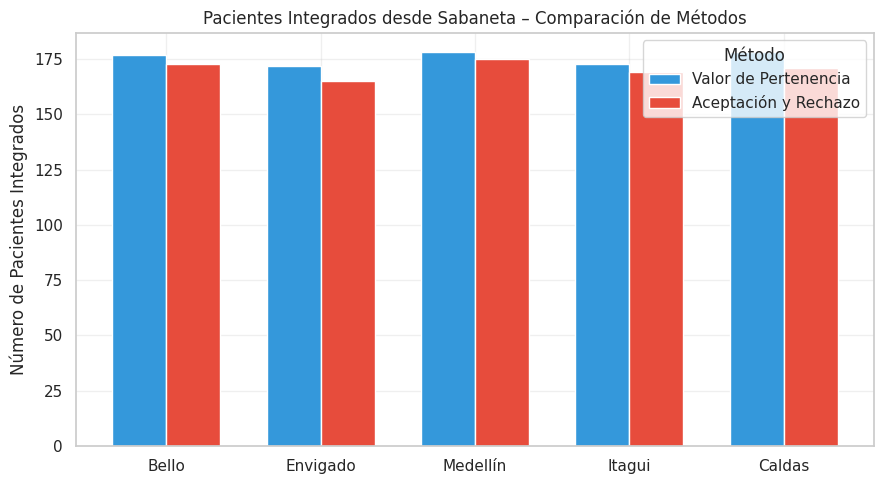

In [53]:
print("\n" + "="*60)
print("  Comparación entre los métodos de integración")
print("="*60)
print(f"\n  {'Sucursal':<12} {'Val. Pertenencia':>18} {'Acep./Rechazo':>15}")
print(f"  {'-'*47}")
for nombre in stats:
    print(f"  {nombre:<12} {conteo_vp[nombre]:>18} {conteo_ar[nombre]:>15}")

plt.figure(figsize=(9, 5))
x     = np.arange(len(stats))
ancho = 0.35
nombres_suc = list(stats.keys())
plt.bar(x - ancho/2, [conteo_vp[n] for n in nombres_suc],
        ancho, label='Valor de Pertenencia', color='#3498db', edgecolor='white')
plt.bar(x + ancho/2, [conteo_ar[n] for n in nombres_suc],
        ancho, label='Aceptación y Rechazo',  color='#e74c3c', edgecolor='white')
plt.xticks(x, nombres_suc)
plt.title("Pacientes Integrados desde Sabaneta – Comparación de Métodos")
plt.ylabel("Número de Pacientes Integrados")
plt.legend(title="Método")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusiones**

La integración de pacientes de la sede Sabaneta hacia las demás sucursales de la red EPS se realizó de manera satisfactoria, el BMI se confirmó como la variable más adecuada para el análisis por su distribución simétrica, disponibilidad en todas las sedes y relevancia clínica en pacientes diabéticos. Otras variables, como la glucosa o la función de pedigrí de diabetes, presentaron limitaciones técnicas que reducían su utilidad como referencia.

En términos de afinidad estadística, Itagüí resultó ser la sucursal más cercana a Sabaneta, con el mayor factor de credibilidad (Z ≈ 47%).

La integración no altera el perfil clínico central de las sedes receptoras. En todos los casos los cambios en la media fueron inferiores al 0.08%, incluso tras incorporar entre 165 y 178 pacientes por sede. Al mismo tiempo, la desviación estándar disminuye entre 8% y 13%, efecto esperado del umbral de selección (VP > 0.90), que filtra pacientes con valores cercanos a la media y reduce la dispersión.

Finalmente, ambos métodos producen resultados muy similares. El método de Valor de Pertenencia integra alrededor de 878 pacientes, mientras que Aceptación/Rechazo integra 853, una diferencia cercana al 3%. Dado que las medias y niveles de dispersión posteriores son prácticamente iguales, el procedimiento puede considerarse robusto.

Como recomendación operativa, se sugiere utilizar el método de Aceptación/Rechazo por su carácter más conservador. Asimismo, Itagüí se perfila como la principal sede receptora, seguida de Medellín y Caldas por su mayor capacidad instalada. En conjunto, los resultados indican que el cierre de Sabaneta no afectaría de forma significativa el perfil clínico de las sedes receptoras.